# Golf Swing Analysis v3 — 100 Practice vs 100 Real Putts

**Conditions:** 4-foot slightly uphill putts, ~10 putts then a pause/reset, repeated.

Full ML pipeline: stroke detection → train/test split → grid search → multi-model comparison.

In [1]:
import fitparse
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.signal import find_peaks

def load_fit(path):
    fitfile = fitparse.FitFile(path)
    records = []
    for record in fitfile.get_messages("record"):
        row = {}
        for field in record.fields:
            row[field.name] = field.value
        records.append(row)
    df = pd.DataFrame(records)
    return df

def show_plot(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=filename))

practice = load_fit("100 practice putts.fit")
real = load_fit("100 Real putts.fit")

features = ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']

practice = practice.dropna(subset=['peak_mag']).reset_index(drop=True)
practice['elapsed'] = range(len(practice))
real = real.dropna(subset=['peak_mag']).reset_index(drop=True)
real['elapsed'] = range(len(real))

print(f"Practice: {len(practice)} seconds of data")
print(f"Real:     {len(real)} seconds of data")

Practice: 502 seconds of data
Real:     698 seconds of data


## Stroke Detection — Visualize Reset Pauses

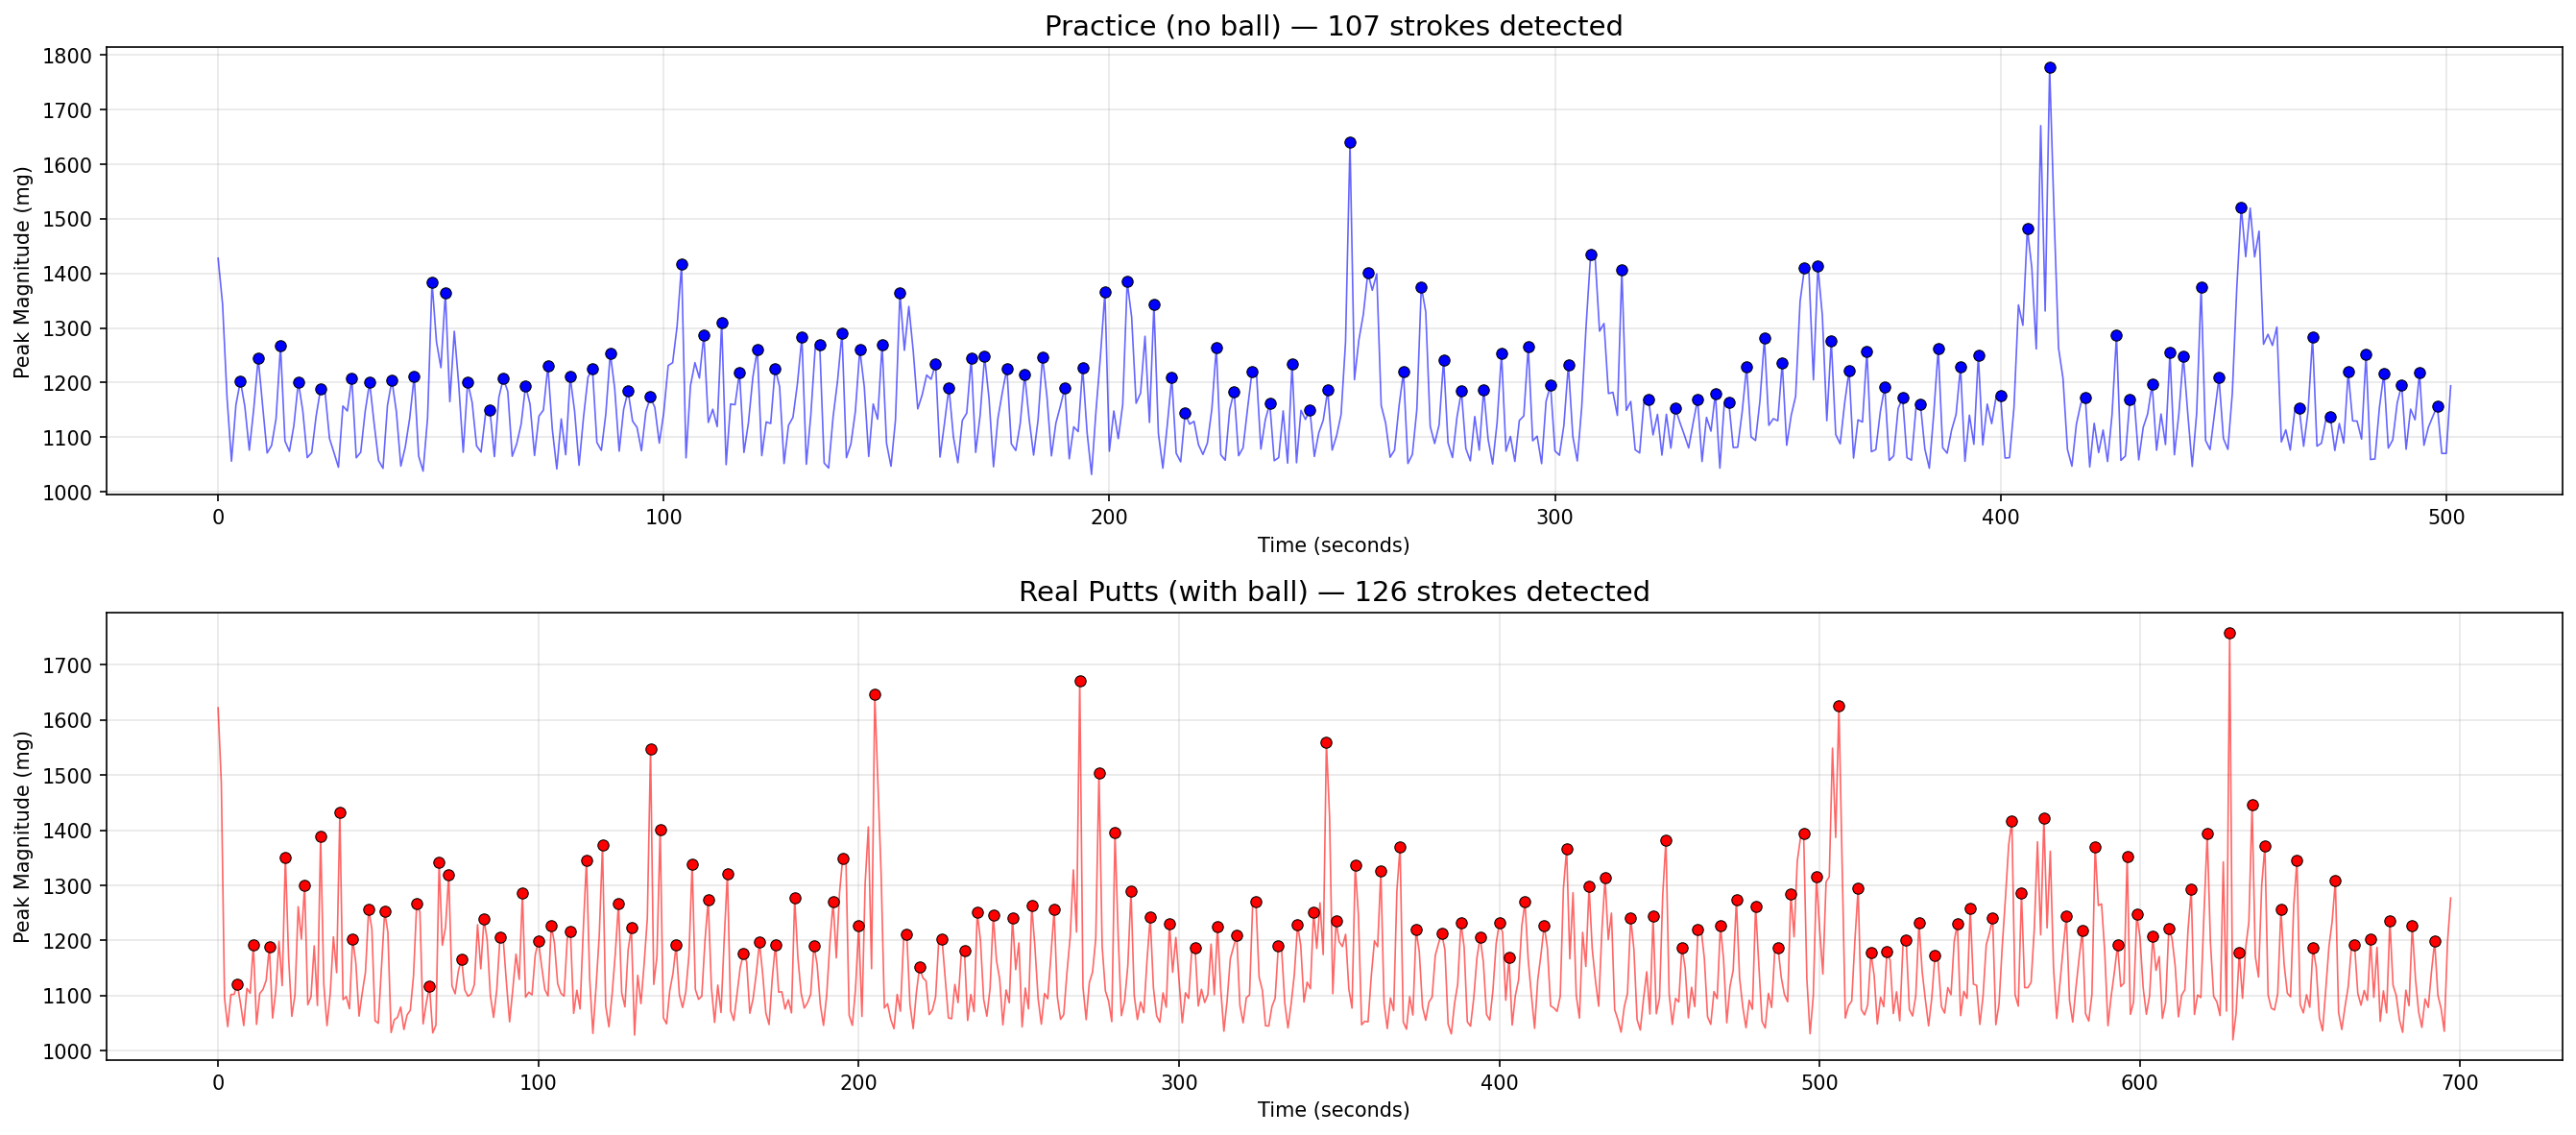

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

for i, (label, df, color) in enumerate([('Practice (no ball)', practice, 'blue'), ('Real Putts (with ball)', real, 'red')]):
    mag = df['peak_mag'].values
    elapsed = df['elapsed'].values
    peaks, _ = find_peaks(mag, distance=3, prominence=50)
    
    axes[i].plot(elapsed, mag, color=color, linewidth=0.8, alpha=0.6)
    axes[i].scatter(elapsed[peaks], mag[peaks], color=color, s=30, zorder=5, edgecolors='black', linewidth=0.5)
    
    axes[i].set_title(f'{label} — {len(peaks)} strokes detected', fontsize=14)
    axes[i].set_ylabel('Peak Magnitude (mg)')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'v3_stroke_detection.png')

## Extract Stroke-Level Features

In [3]:
p_peaks, _ = find_peaks(practice['peak_mag'].values, distance=3, prominence=50)
r_peaks, _ = find_peaks(real['peak_mag'].values, distance=3, prominence=50)

p_strokes = practice.iloc[p_peaks][features].copy()
p_strokes['type'] = 'practice'
r_strokes = real.iloc[r_peaks][features].copy()
r_strokes['type'] = 'real'

print(f"Practice strokes detected: {len(p_strokes)} (target: 100)")
print(f"Real strokes detected:     {len(r_strokes)} (target: 100)")

all_strokes = pd.concat([p_strokes, r_strokes], ignore_index=True)
print(f"Total: {len(all_strokes)} samples for ML")

Practice strokes detected: 107 (target: 100)
Real strokes detected:     126 (target: 100)
Total: 233 samples for ML


## Train/Test Split + Grid Search Across Multiple Models

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = all_strokes[features].values
y = (all_strokes['type'] == 'real').astype(int).values

# 70/30 stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {len(y_train)} samples ({sum(y_train==0)} practice, {sum(y_train==1)} real)")
print(f"Test:  {len(y_test)} samples ({sum(y_test==0)} practice, {sum(y_test==1)} real)")

# Define models and their grids
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10, None],
            'min_samples_leaf': [1, 3, 5],
        }
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [2, 3, 5],
            'learning_rate': [0.05, 0.1, 0.2],
        }
    ),
    'SVM (RBF)': (
        SVC(kernel='rbf', random_state=42),
        {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 0.01, 0.1, 1],
        }
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=42),
        {
            'C': [0.01, 0.1, 1, 10, 100],
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
        }
    ),
}

results = {}
for name, (model, grid) in models.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train_s, y_train)
    test_acc = gs.score(X_test_s, y_test)
    results[name] = {
        'best_params': gs.best_params_,
        'cv_acc': gs.best_score_,
        'test_acc': test_acc,
        'estimator': gs.best_estimator_,
    }
    print(f"\n{name}")
    print(f"  Best params: {gs.best_params_}")
    print(f"  CV accuracy:   {gs.best_score_:.1%}")
    print(f"  Test accuracy: {test_acc:.1%}")

Train: 163 samples (75 practice, 88 real)
Test:  70 samples (32 practice, 38 real)

Random Forest
  Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
  CV accuracy:   84.6%
  Test accuracy: 85.7%

Gradient Boosting
  Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
  CV accuracy:   83.4%
  Test accuracy: 81.4%

SVM (RBF)
  Best params: {'C': 10, 'gamma': 'scale'}
  CV accuracy:   85.2%
  Test accuracy: 82.9%

Logistic Regression
  Best params: {'C': 1}
  CV accuracy:   76.0%
  Test accuracy: 71.4%

KNN
  Best params: {'n_neighbors': 3, 'weights': 'uniform'}
  CV accuracy:   85.3%
  Test accuracy: 78.6%



Random Forest
  Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
  CV accuracy:   84.6%
  Test accuracy: 85.7%



Gradient Boosting
  Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
  CV accuracy:   83.4%
  Test accuracy: 81.4%

SVM (RBF)
  Best params: {'C': 10, 'gamma': 'scale'}
  CV accuracy:   85.2%
  Test accuracy: 82.9%

Logistic Regression
  Best params: {'C': 1}
  CV accuracy:   76.0%
  Test accuracy: 71.4%

KNN
  Best params: {'n_neighbors': 3, 'weights': 'uniform'}
  CV accuracy:   85.3%
  Test accuracy: 78.6%


## Model Comparison & Best Model Detail

              Model  CV Accuracy  Test Accuracy
      Random Forest     0.846212       0.857143
          SVM (RBF)     0.852083       0.828571
  Gradient Boosting     0.834280       0.814286
                KNN     0.853220       0.785714
Logistic Regression     0.760417       0.714286


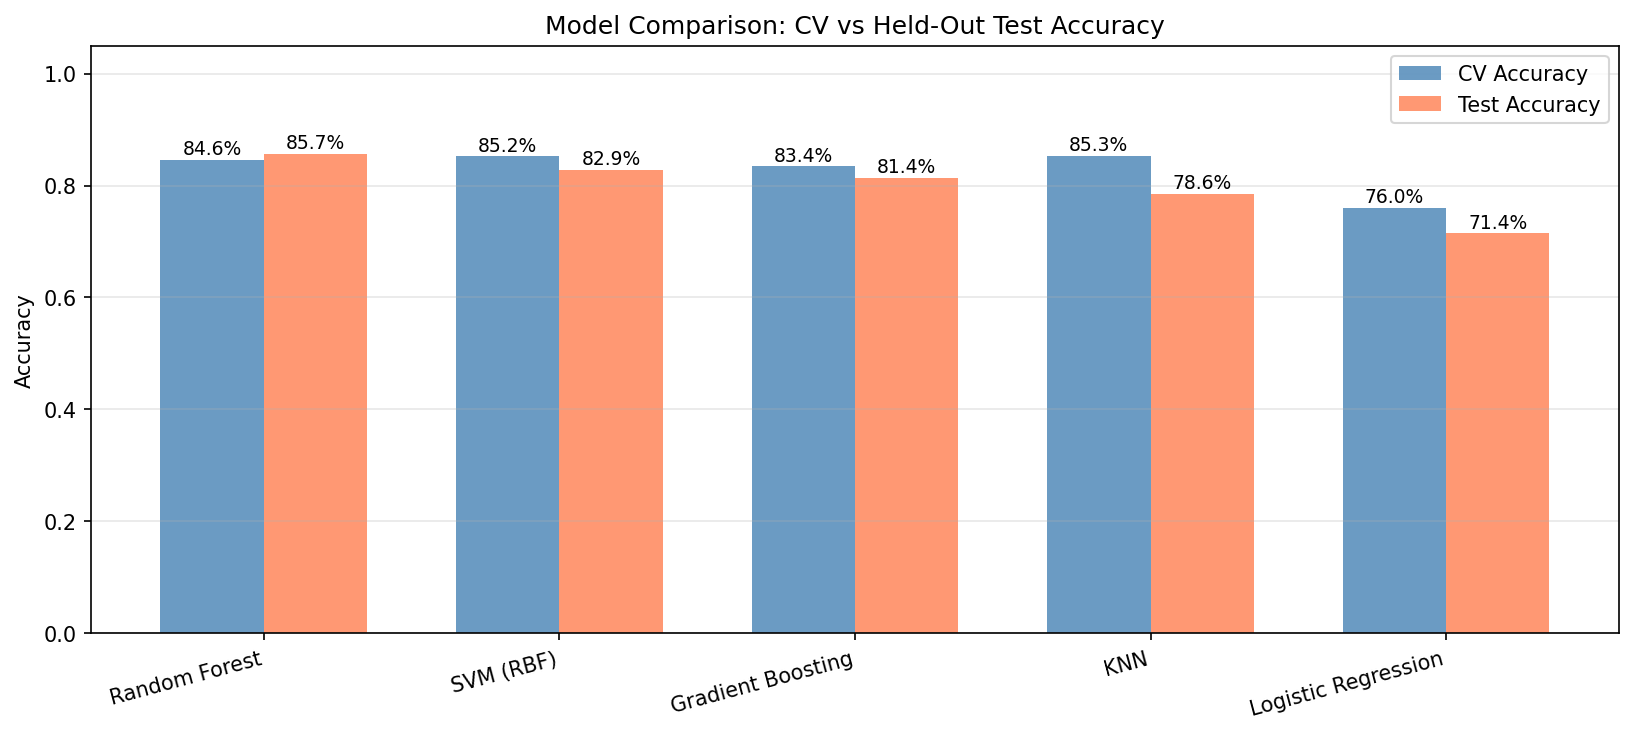


BEST MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

    Practice       0.84      0.84      0.84        32
        Real       0.87      0.87      0.87        38

    accuracy                           0.86        70
   macro avg       0.86      0.86      0.86        70
weighted avg       0.86      0.86      0.86        70

Confusion Matrix:
              Predicted
              Prac  Real
Actual Prac     27     5
Actual Real      5    33


In [5]:
summary = pd.DataFrame([
    {'Model': k, 'CV Accuracy': v['cv_acc'], 'Test Accuracy': v['test_acc']}
    for k, v in results.items()
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary['CV Accuracy'], w, label='CV Accuracy', color='steelblue', alpha=0.8)
ax.bar(x + w/2, summary['Test Accuracy'], w, label='Test Accuracy', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: CV vs Held-Out Test Accuracy')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, (cv, test) in enumerate(zip(summary['CV Accuracy'], summary['Test Accuracy'])):
    ax.text(i - w/2, cv + 0.01, f'{cv:.1%}', ha='center', fontsize=9)
    ax.text(i + w/2, test + 0.01, f'{test:.1%}', ha='center', fontsize=9)

plt.tight_layout()
show_plot(fig, 'v3_model_comparison.png')

# Best model details
best_name = summary.iloc[0]['Model']
best = results[best_name]['estimator']
y_pred = best.predict(X_test_s)

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_name}")
print(f"{'='*60}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Practice', 'Real']))

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:")
print(f"              Predicted")
print(f"              Prac  Real")
print(f"Actual Prac    {cm[0][0]:3d}   {cm[0][1]:3d}")
print(f"Actual Real    {cm[1][0]:3d}   {cm[1][1]:3d}")

## Feature Importance (from best tree-based model)

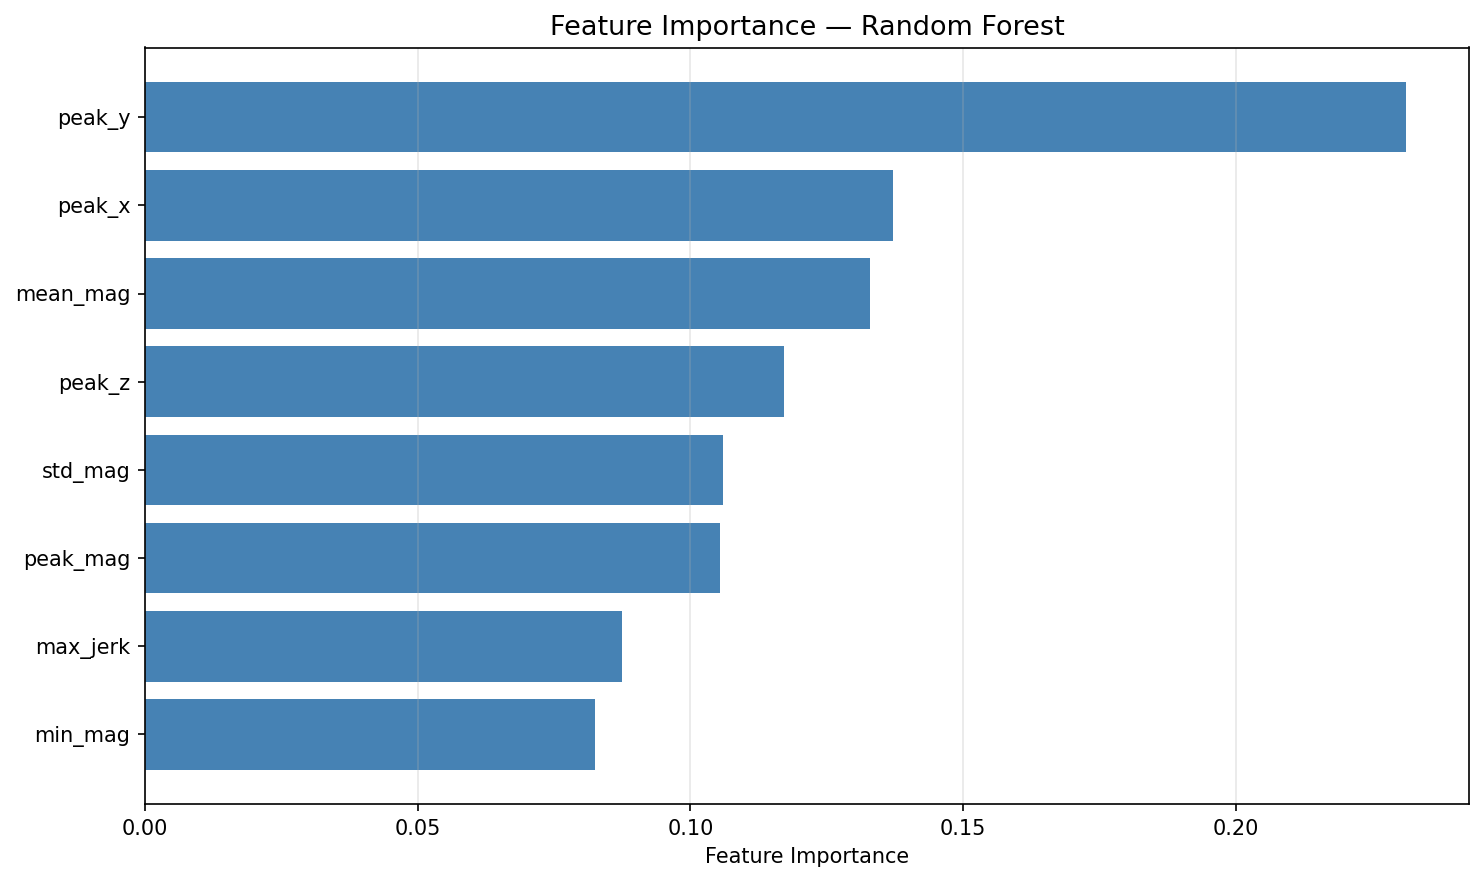

Top features (Random Forest):
  peak_y      : 0.231
  peak_x      : 0.137
  mean_mag    : 0.133
  peak_z      : 0.117
  std_mag     : 0.106
  peak_mag    : 0.105
  max_jerk    : 0.087
  min_mag     : 0.082


Exception ignored in: <function ResourceTracker.__del__ at 0x7fe217f8d260>
Traceback (most recent call last):
  File "/home/g16/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/g16/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/g16/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x76c32e595260>
Traceback (most recent call last):
  File "/home/g16/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/g16/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/g16/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x772fd01

In [6]:
# Use the best tree-based model for feature importance
tree_models = {k: v for k, v in results.items() if hasattr(v['estimator'], 'feature_importances_')}
best_tree_name = max(tree_models, key=lambda k: tree_models[k]['test_acc'])
best_tree = tree_models[best_tree_name]['estimator']

importances = best_tree.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(features)), importances[sorted_idx], color='steelblue')
ax.set_yticks(range(len(features)))
ax.set_yticklabels([features[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance')
ax.set_title(f'Feature Importance — {best_tree_name}', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
show_plot(fig, 'v3_feature_importance.png')

print(f"Top features ({best_tree_name}):")
for i in sorted_idx[::-1]:
    print(f"  {features[i]:12s}: {importances[i]:.3f}")